# Notebook 04 — Data Quality, Expected Power Model & SHAP

**Paper**: *An Explainable, Data-Efficient Framework for Multi-Class Fault Diagnosis and Carbon-Loss Quantification in Early-Stage Solar PV Monitoring*

This notebook supports:
- **Section III** — Dataset & Data Quality
- **Section IV-A** — Physics-based + XGBoost expected power model
- **Section IV-B** — Weather-normalized peer comparison
- **Section IV-E (partial)** — SHAP for regression

---

In [1]:
# === Setup ===
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Ensure project root is on path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from scripts.paper.data_loader import (
    get_paper_dataset, load_raw_data, apply_dc_correction,
    PLANT1_ID, PLANT2_ID, EMISSION_FACTOR, INTERVAL_HOURS
)
from scripts.paper.plot_utils import (
    set_paper_style, save_fig, COLORS, ANOMALY_COLORS,
    dual_column_figsize, single_column_figsize, format_thousands
)

set_paper_style()
print('Setup complete.')

Setup complete.


## 1. Data Loading & Quality

### 1.1 Load raw data and apply corrections

The dataset covers **34 days** of operation (2020-05-15 to 2020-06-17) from **two solar PV plants in India**, each with **22 inverters** and **1 weather sensor**. We frame this as an **early-commissioning scenario**: Can a newly installed plant be reliably monitored for faults within its first month of operation, before sufficient historical data exists for seasonal models?

In [2]:
# Load the full analytical dataset
df = get_paper_dataset(data_dir=os.path.join(PROJECT_ROOT, 'data', 'raw'))

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df["DATE_TIME"].min()} → {df["DATE_TIME"].max()}')
print(f'Plants: {df["PLANT_ID"].unique()}')
print(f'Inverters per plant:')
print(df.groupby('PLANT_ID')['SOURCE_KEY'].nunique())
print(f'\nDaytime records: {df["IS_DAY"].sum():,} / {len(df):,} total')
print(f'Interval: 15 minutes ({INTERVAL_HOURS} hours)')
print(f'Timestamps per plant: ~{len(df) // 44:,}')

Dataset shape: (136476, 29)
Date range: 2020-05-15 00:00:00 → 2020-06-17 23:45:00
Plants: [4135001 4136001]
Inverters per plant:
PLANT_ID
4135001    22
4136001    22
Name: SOURCE_KEY, dtype: int64

Daytime records: 77,098 / 136,476 total
Interval: 15 minutes (0.25 hours)
Timestamps per plant: ~3,101


### 1.2 Data Quality Issue: Plant 1 DC_POWER Scale Error

We discovered that Plant 1's `DC_POWER` values are **10× higher** than expected, resulting in an unrealistic inverter conversion efficiency of ~9.8% (vs. the expected 93–98%). This is a **data recording/unit error**, not an equipment failure. Many public notebooks using this Kaggle dataset may have overlooked this issue.

**Contribution**: We document this data quality fix as a verifiable, community-valuable finding.

  → Saved: D:\Aptech\Du_an\reports\figures\paper\fig_01_data_quality_before_after.png


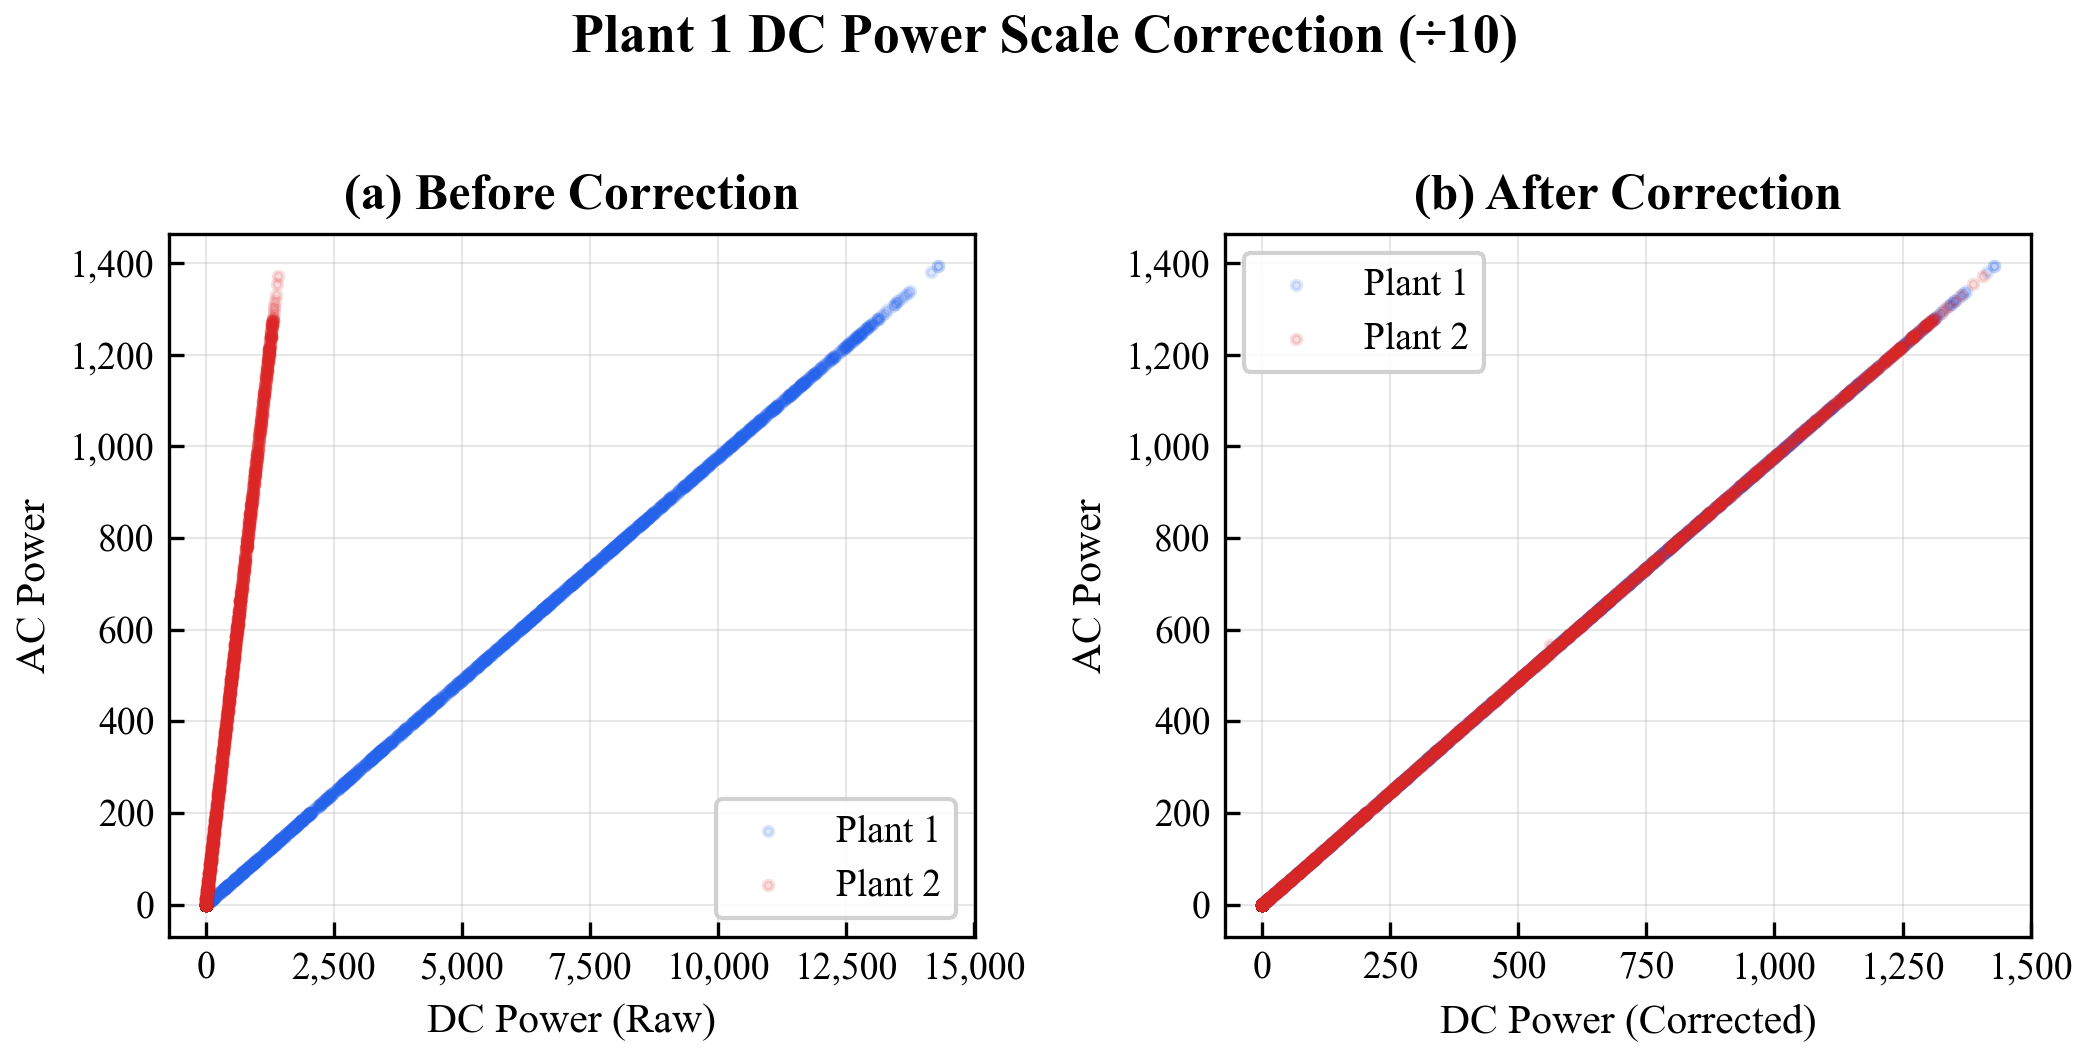

In [3]:
# === Fig 1: Before/After DC Power Correction ===

# Daytime data only
day = df[df['IS_DAY'] == True].copy()

fig, axes = plt.subplots(1, 2, figsize=dual_column_figsize(3.5))

# --- Before correction ---
for pid, color, label in [(PLANT1_ID, COLORS['plant1'], 'Plant 1'),
                          (PLANT2_ID, COLORS['plant2'], 'Plant 2')]:
    subset = day[day['PLANT_ID'] == pid].sample(min(2000, len(day[day['PLANT_ID'] == pid])), random_state=42)
    axes[0].scatter(subset['DC_POWER_RAW'], subset['AC_POWER'],
                    alpha=0.15, s=5, color=color, label=label)
axes[0].set_xlabel('DC Power (Raw)')
axes[0].set_ylabel('AC Power')
axes[0].set_title('(a) Before Correction')
axes[0].legend()
format_thousands(axes[0], 'both')

# --- After correction ---
for pid, color, label in [(PLANT1_ID, COLORS['plant1'], 'Plant 1'),
                          (PLANT2_ID, COLORS['plant2'], 'Plant 2')]:
    subset = day[day['PLANT_ID'] == pid].sample(min(2000, len(day[day['PLANT_ID'] == pid])), random_state=42)
    axes[1].scatter(subset['DC_POWER_CORRECTED'], subset['AC_POWER'],
                    alpha=0.15, s=5, color=color, label=label)
axes[1].set_xlabel('DC Power (Corrected)')
axes[1].set_ylabel('AC Power')
axes[1].set_title('(b) After Correction')
axes[1].legend()
format_thousands(axes[1], 'both')

plt.suptitle('Plant 1 DC Power Scale Correction (÷10)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'fig_01_data_quality_before_after')
plt.show()

  → Saved: D:\Aptech\Du_an\reports\figures\paper\fig_02_efficiency_distribution.png


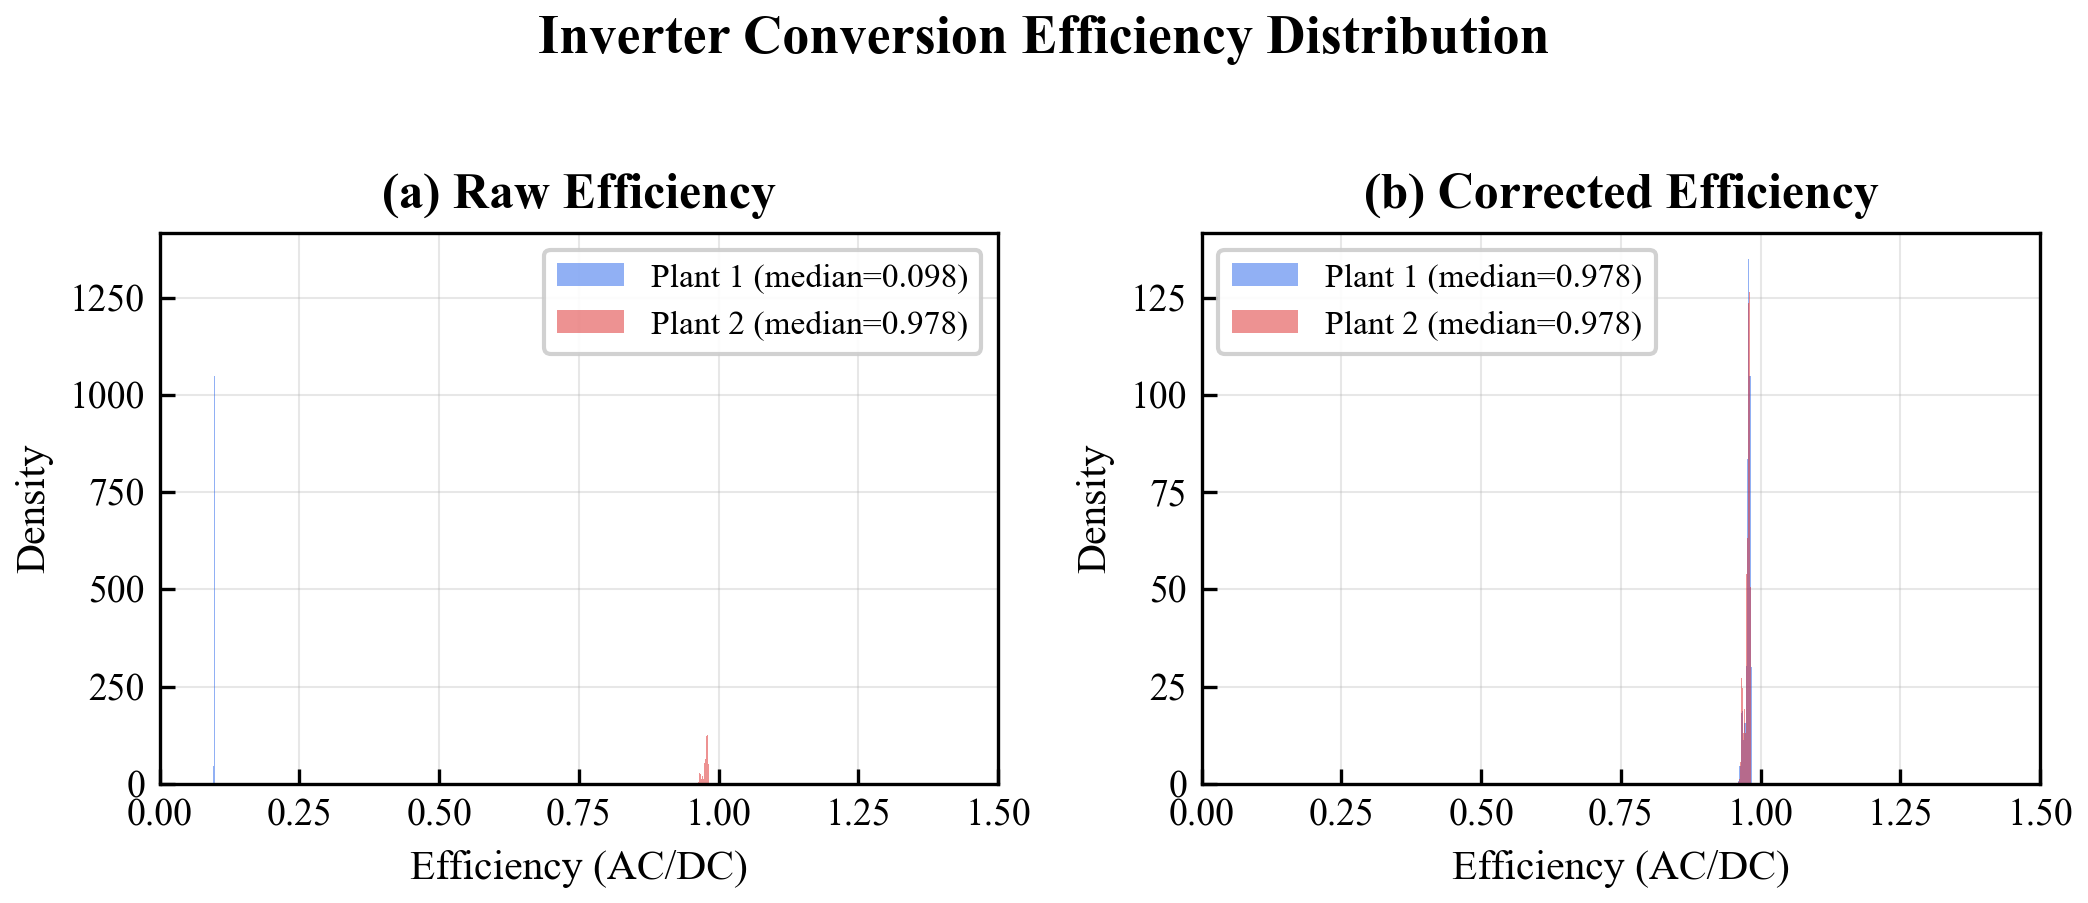

In [4]:
# === Fig 2: Efficiency Distribution Before/After ===

fig, axes = plt.subplots(1, 2, figsize=dual_column_figsize(3.0))

# Filter valid efficiency values
valid_eff = day[(day['EFFICIENCY_RAW'].notna()) & (day['EFFICIENCY_RAW'] > 0) & (day['EFFICIENCY_RAW'] < 2)]
valid_eff_c = day[(day['EFFICIENCY_CORRECTED'].notna()) & (day['EFFICIENCY_CORRECTED'] > 0) & (day['EFFICIENCY_CORRECTED'] < 2)]

for pid, color, label in [(PLANT1_ID, COLORS['plant1'], 'Plant 1'),
                          (PLANT2_ID, COLORS['plant2'], 'Plant 2')]:
    subset = valid_eff[valid_eff['PLANT_ID'] == pid]['EFFICIENCY_RAW']
    axes[0].hist(subset, bins=50, alpha=0.5, color=color, label=f'{label} (median={subset.median():.3f})', density=True)
axes[0].set_xlabel('Efficiency (AC/DC)')
axes[0].set_ylabel('Density')
axes[0].set_title('(a) Raw Efficiency')
axes[0].legend(fontsize=8)
axes[0].set_xlim(0, 1.5)

for pid, color, label in [(PLANT1_ID, COLORS['plant1'], 'Plant 1'),
                          (PLANT2_ID, COLORS['plant2'], 'Plant 2')]:
    subset = valid_eff_c[valid_eff_c['PLANT_ID'] == pid]['EFFICIENCY_CORRECTED']
    axes[1].hist(subset, bins=50, alpha=0.5, color=color, label=f'{label} (median={subset.median():.3f})', density=True)
axes[1].set_xlabel('Efficiency (AC/DC)')
axes[1].set_ylabel('Density')
axes[1].set_title('(b) Corrected Efficiency')
axes[1].legend(fontsize=8)
axes[1].set_xlim(0, 1.5)

plt.suptitle('Inverter Conversion Efficiency Distribution', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'fig_02_efficiency_distribution')
plt.show()

In [5]:
# === Table: Efficiency summary (for paper Section III) ===

eff_summary = []
for pid, name in [(PLANT1_ID, 'Plant 1'), (PLANT2_ID, 'Plant 2')]:
    sub = day[day['PLANT_ID'] == pid]
    raw_valid = sub[(sub['EFFICIENCY_RAW'].notna()) & (sub['EFFICIENCY_RAW'] > 0)]['EFFICIENCY_RAW']
    corr_valid = sub[(sub['EFFICIENCY_CORRECTED'].notna()) & (sub['EFFICIENCY_CORRECTED'] > 0)]['EFFICIENCY_CORRECTED']
    eff_summary.append({
        'Plant': name,
        'Raw Eff. Median': f'{raw_valid.median():.4f}',
        'Raw Eff. (%)': f'{raw_valid.median()*100:.2f}%',
        'Corrected Eff. Median': f'{corr_valid.median():.4f}',
        'Corrected Eff. (%)': f'{corr_valid.median()*100:.2f}%',
        'Realistic?': '✓' if corr_valid.median() > 0.85 else '✗',
    })

eff_df = pd.DataFrame(eff_summary)
print('=== Efficiency Summary (Paper Section III) ===')
print(eff_df.to_string(index=False))

=== Efficiency Summary (Paper Section III) ===
  Plant Raw Eff. Median Raw Eff. (%) Corrected Eff. Median Corrected Eff. (%) Realistic?
Plant 1          0.0978        9.78%                0.9785             97.85%          ✓
Plant 2          0.9784       97.84%                0.9784             97.84%          ✓


## 2. Expected Power Regression (XGBoost)

### 2.1 Chronological Train/Test Split

We use a **time-based split** (first 27 days for training, last 7 days for testing) to avoid data leakage — this is critical for time-series problems and a point the sibling paper (Nahar 2025) did not explicitly address.

### 2.2 Model Design
We train **one XGBoost regressor per plant** on daytime records from all inverters (excluding the known anomalous inverter `bvBOhCH3iADSZry` during training to avoid learning its degraded patterns).

In [6]:
# === Chronological split ===

# Only daytime records with valid data
day_valid = day[
    (day['IRRADIATION'] > 0) &
    (day['AC_POWER'].notna()) &
    (day['DC_POWER_CORRECTED'].notna()) &
    (day['MODULE_TEMPERATURE'].notna())
].copy()

# Split date: first 27 days train, last 7 days test
all_dates = sorted(day_valid['DATE'].unique())
split_idx = int(len(all_dates) * 0.8)  # ~27 days out of 34
train_dates = set(all_dates[:split_idx])
test_dates = set(all_dates[split_idx:])

print(f'Total unique dates: {len(all_dates)}')
print(f'Train dates: {len(train_dates)} ({min(train_dates)} → {max(train_dates)})')
print(f'Test dates:  {len(test_dates)} ({min(test_dates)} → {max(test_dates)})')

# Features for regression
FEATURES = [
    'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE',
    'HOUR_SIN', 'HOUR_COS',
]
TARGET = 'AC_POWER'

# Exclude target anomalous inverter from training
EXCLUDE_FROM_TRAIN = ['bvBOhCH3iADSZry']

Total unique dates: 34
Train dates: 27 (2020-05-15 → 2020-06-10)
Test dates:  7 (2020-06-11 → 2020-06-17)


In [7]:
# === Train XGBoost per plant ===

models = {}
results_list = []

for plant_id, plant_name in [(PLANT1_ID, 'Plant 1'), (PLANT2_ID, 'Plant 2')]:
    print(f'\n{"="*60}')
    print(f'Training XGBoost for {plant_name} (ID: {plant_id})')
    print(f'{"="*60}')

    plant_data = day_valid[day_valid['PLANT_ID'] == plant_id].copy()

    # Train set: exclude anomalous inverter
    train_mask = (
        plant_data['DATE'].isin(train_dates) &
        ~plant_data['SOURCE_KEY'].isin(EXCLUDE_FROM_TRAIN)
    )
    test_mask = plant_data['DATE'].isin(test_dates)

    X_train = plant_data.loc[train_mask, FEATURES]
    y_train = plant_data.loc[train_mask, TARGET]
    X_test = plant_data.loc[test_mask, FEATURES]
    y_test = plant_data.loc[test_mask, TARGET]

    print(f'  Train: {len(X_train):,} records')
    print(f'  Test:  {len(X_test):,} records')

    # Train XGBoost
    model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    # Predict
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Metrics
    for split_name, y_true, y_pred in [('Train', y_train, y_pred_train), ('Test', y_test, y_pred_test)]:
        r2 = r2_score(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        # MAPE (avoid div by zero)
        mask_nonzero = y_true > 0
        mape = np.mean(np.abs((y_true[mask_nonzero] - y_pred[mask_nonzero]) / y_true[mask_nonzero])) * 100

        print(f'  {split_name}: R²={r2:.4f}, MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.2f}%')
        results_list.append({
            'Plant': plant_name,
            'Split': split_name,
            'R²': round(r2, 4),
            'MAE (kW)': round(mae, 2),
            'RMSE (kW)': round(rmse, 2),
            'MAPE (%)': round(mape, 2),
        })

    models[plant_id] = model

# === Table I: Regression Results ===
results_df = pd.DataFrame(results_list)
print('\n=== Table I: Regression Results ===')
print(results_df.to_string(index=False))
results_df.to_csv(os.path.join(PROJECT_ROOT, 'data', 'processed', 'paper', 'regression_results.csv'), index=False)


Training XGBoost for Plant 1 (ID: 4135001)
  Train: 28,895 records
  Test:  8,096 records


  Train: R²=0.9775, MAE=29.10, RMSE=58.00, MAPE=6.03%
  Test: R²=0.9619, MAE=31.08, RMSE=68.59, MAPE=9.24%

Training XGBoost for Plant 2 (ID: 4136001)
  Train: 30,230 records
  Test:  8,492 records


  Train: R²=0.5403, MAE=156.72, RMSE=279.36, MAPE=22.18%
  Test: R²=0.5386, MAE=101.45, RMSE=199.23, MAPE=33.38%

=== Table I: Regression Results ===
  Plant Split     R²  MAE (kW)  RMSE (kW)  MAPE (%)
Plant 1 Train 0.9775     29.10      58.00      6.03
Plant 1  Test 0.9619     31.08      68.59      9.24
Plant 2 Train 0.5403    156.72     279.36     22.18
Plant 2  Test 0.5386    101.45     199.23     33.38


  → Saved: D:\Aptech\Du_an\reports\figures\paper\fig_03_regression_actual_vs_predicted.png


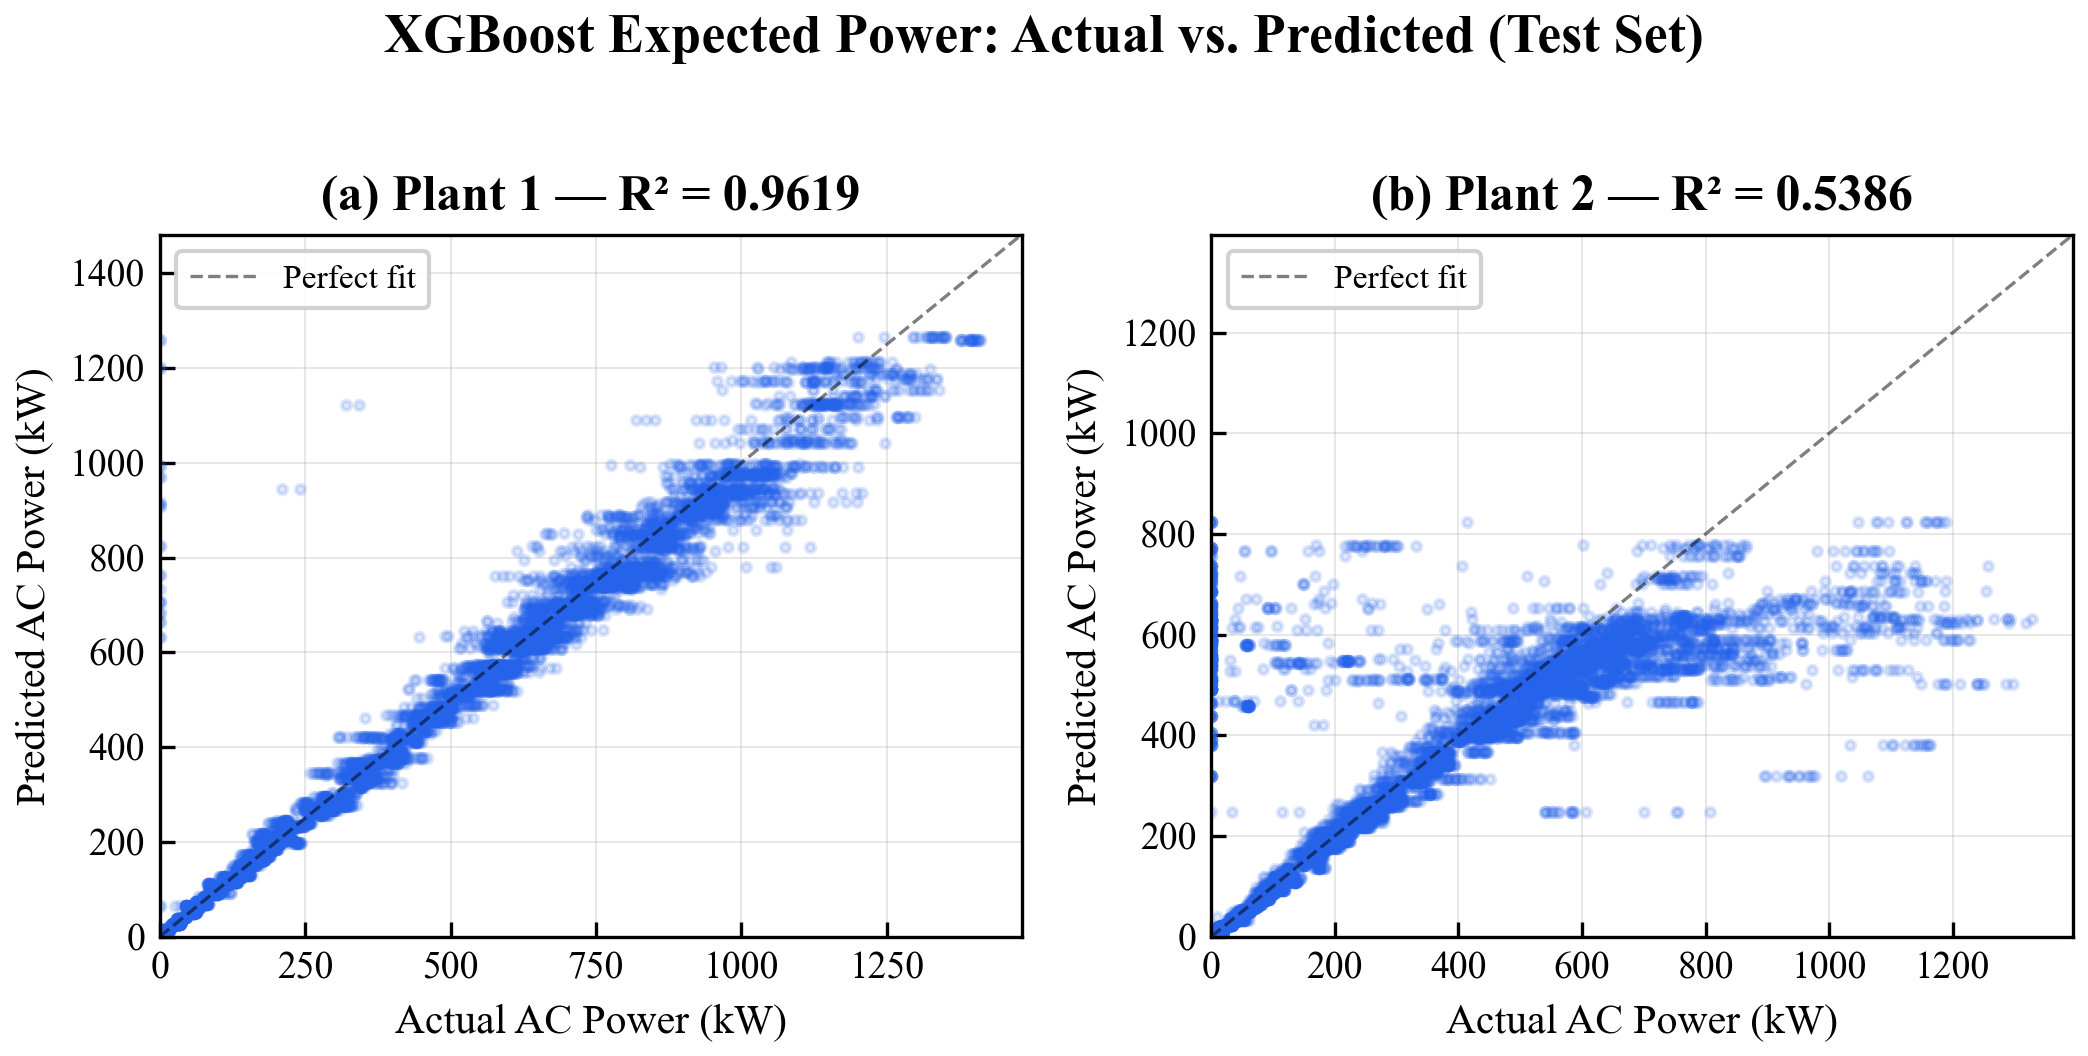

In [8]:
# === Fig 3: Actual vs Expected AC Power (Test Set) ===

fig, axes = plt.subplots(1, 2, figsize=dual_column_figsize(3.5))

for i, (plant_id, plant_name) in enumerate([(PLANT1_ID, 'Plant 1'), (PLANT2_ID, 'Plant 2')]):
    plant_data = day_valid[(day_valid['PLANT_ID'] == plant_id) & (day_valid['DATE'].isin(test_dates))]
    X = plant_data[FEATURES]
    y_true = plant_data[TARGET]
    y_pred = models[plant_id].predict(X)

    r2 = r2_score(y_true, y_pred)

    axes[i].scatter(y_true, y_pred, alpha=0.15, s=5, color=COLORS['primary'])
    lim = max(y_true.max(), y_pred.max()) * 1.05
    axes[i].plot([0, lim], [0, lim], 'k--', linewidth=0.8, alpha=0.5, label='Perfect fit')
    axes[i].set_xlabel('Actual AC Power (kW)')
    axes[i].set_ylabel('Predicted AC Power (kW)')
    axes[i].set_title(f'({chr(97+i)}) {plant_name} — R² = {r2:.4f}')
    axes[i].set_xlim(0, lim)
    axes[i].set_ylim(0, lim)
    axes[i].legend(loc='upper left', fontsize=8)

plt.suptitle('XGBoost Expected Power: Actual vs. Predicted (Test Set)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'fig_03_regression_actual_vs_predicted')
plt.show()

## 3. SHAP Analysis for Regression

We use SHAP (SHapley Additive exPlanations) to validate that our regression model captures physically meaningful relationships. **IRRADIATION** should dominate, consistent with PV physics.

In [9]:
# === SHAP for regression (using Plant 1 model as primary) ===

# Use a subsample for SHAP computation efficiency
plant1_test = day_valid[
    (day_valid['PLANT_ID'] == PLANT1_ID) &
    (day_valid['DATE'].isin(test_dates))
][FEATURES]

shap_sample = plant1_test.sample(min(1000, len(plant1_test)), random_state=42)

explainer = shap.TreeExplainer(models[PLANT1_ID])
shap_values = explainer.shap_values(shap_sample)

print(f'SHAP values shape: {shap_values.shape}')
print(f'Features: {FEATURES}')

SHAP values shape: (1000, 5)
Features: ['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'HOUR_SIN', 'HOUR_COS']


  → Saved: D:\Aptech\Du_an\reports\figures\paper\fig_04_shap_feature_importance.png


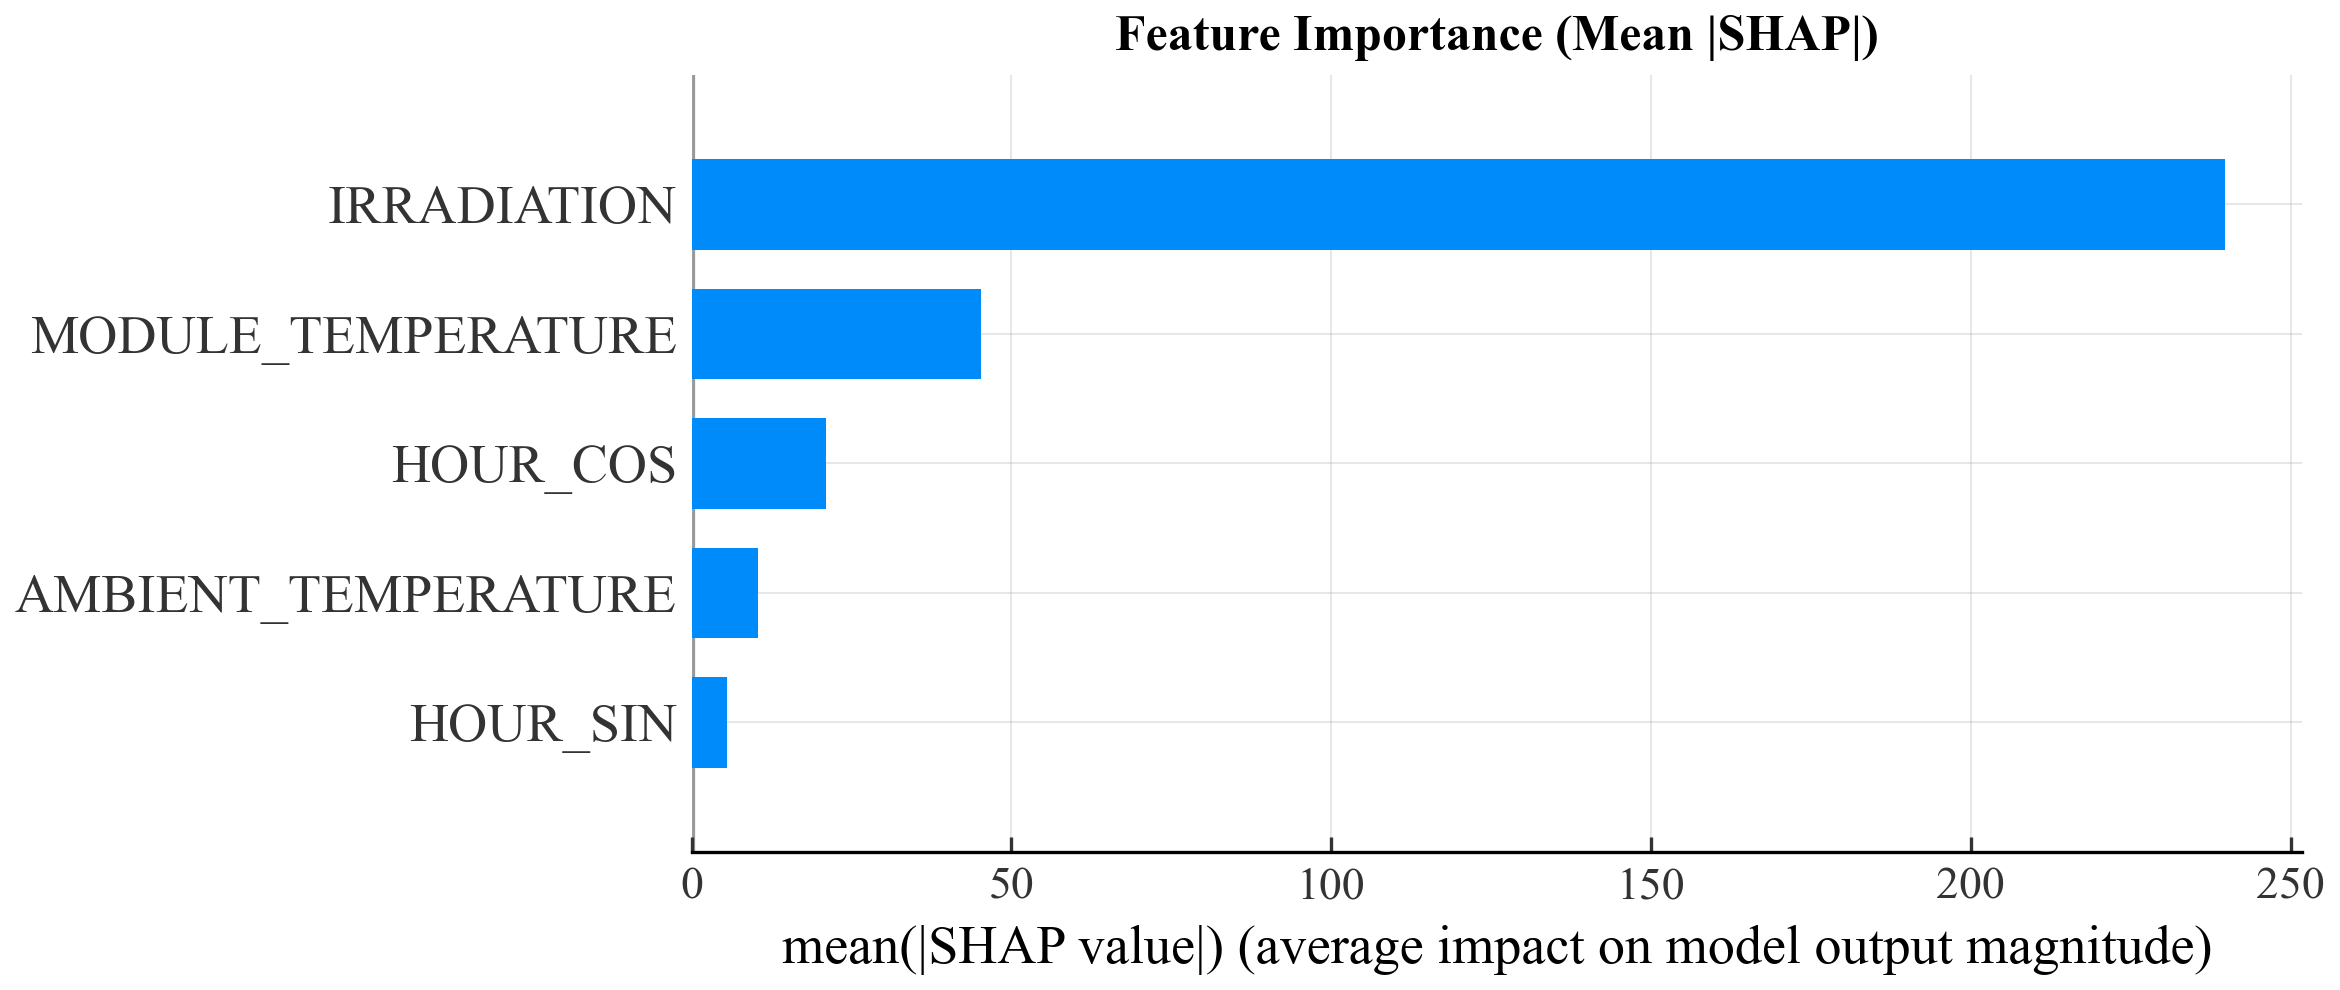

In [10]:
# === Fig 4: SHAP Feature Importance (Bar) ===

fig, ax = plt.subplots(figsize=single_column_figsize(3.0))
shap.summary_plot(shap_values, shap_sample, plot_type='bar', show=False,
                  feature_names=FEATURES)
plt.title('Feature Importance (Mean |SHAP|)', fontsize=12, fontweight='bold')
plt.tight_layout()
save_fig(plt.gcf(), 'fig_04_shap_feature_importance')
plt.show()

  → Saved: D:\Aptech\Du_an\reports\figures\paper\fig_05_shap_beeswarm.png


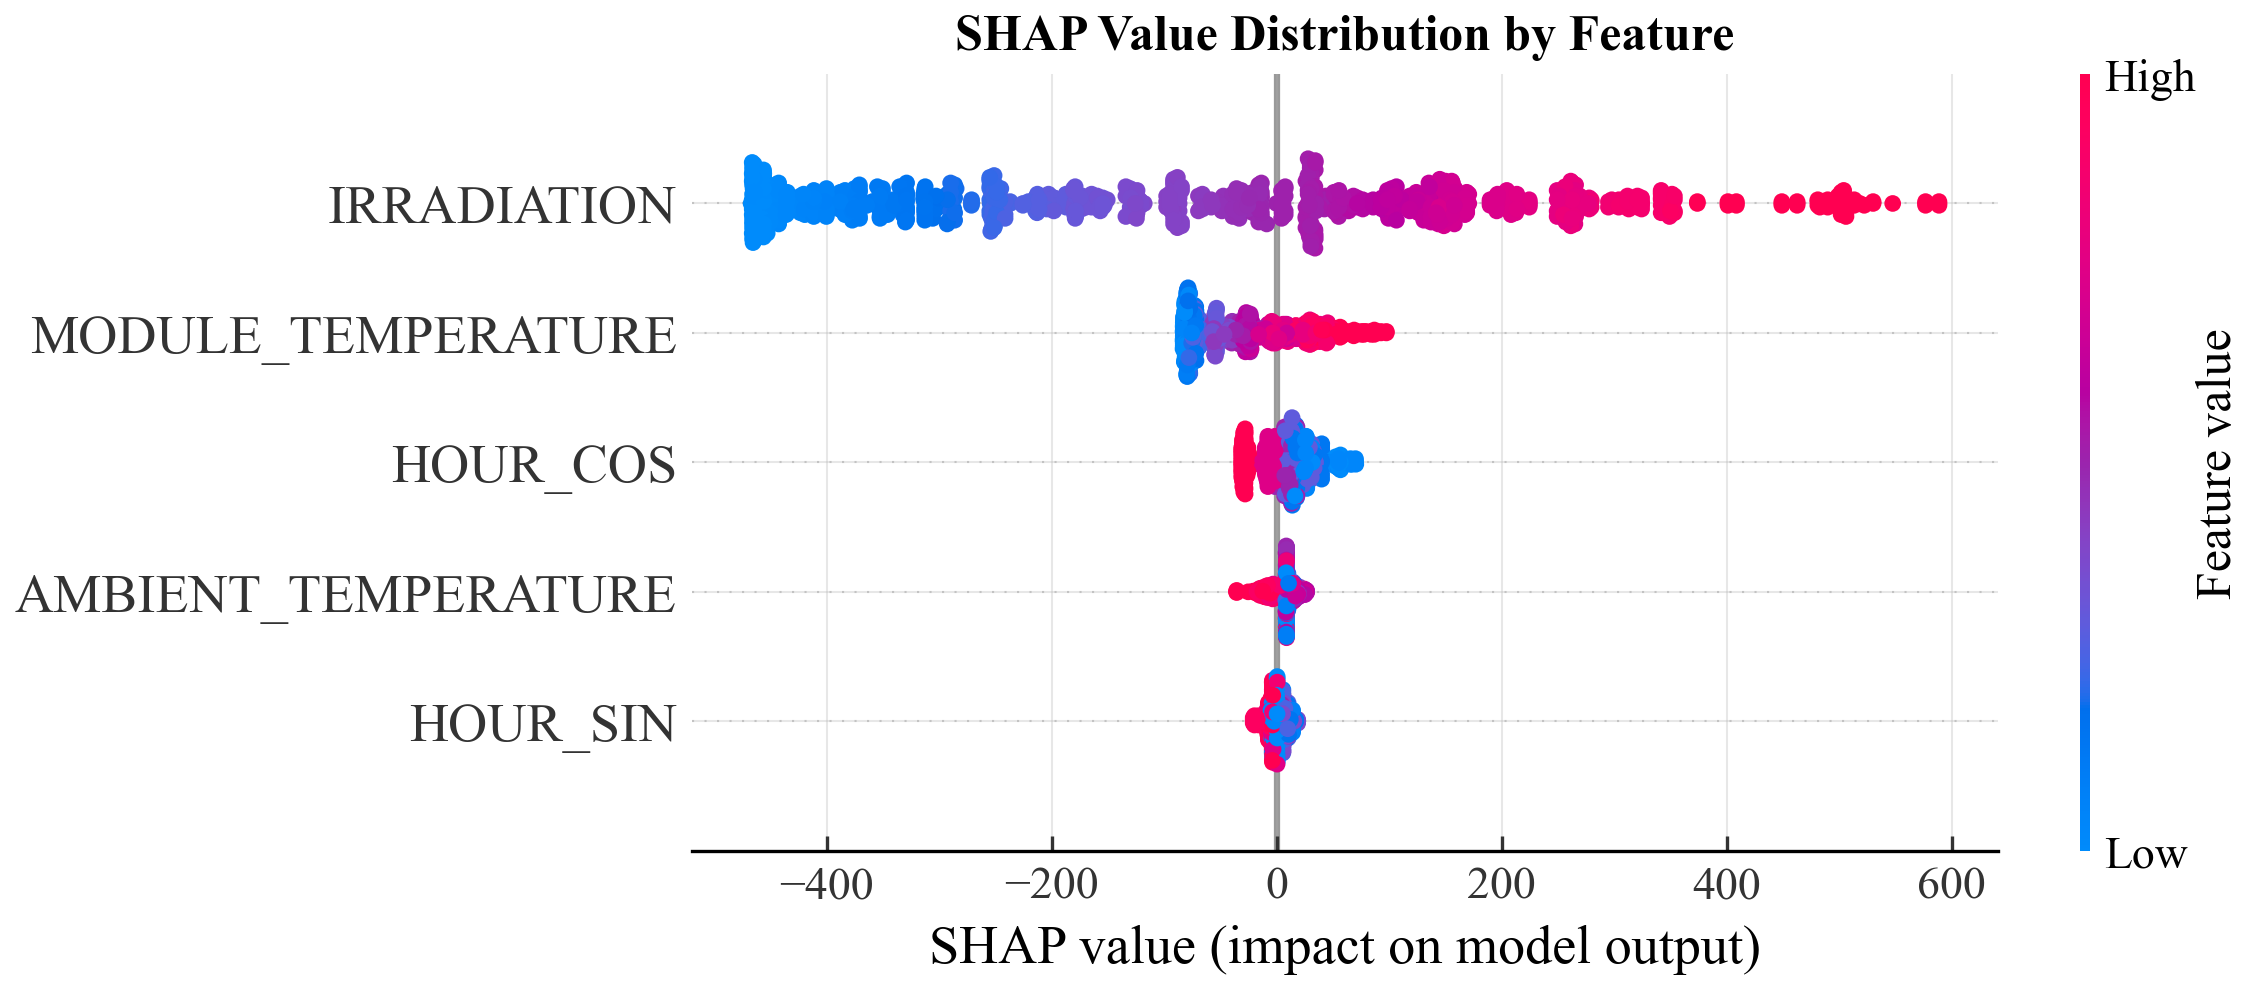

In [11]:
# === Fig 5: SHAP Beeswarm Plot ===

fig, ax = plt.subplots(figsize=single_column_figsize(3.5))
shap.summary_plot(shap_values, shap_sample, show=False,
                  feature_names=FEATURES)
plt.title('SHAP Value Distribution by Feature', fontsize=12, fontweight='bold')
plt.tight_layout()
save_fig(plt.gcf(), 'fig_05_shap_beeswarm')
plt.show()

## 4. Generate Expected Power for Full Dataset

We generate `EXPECTED_AC_POWER` for **all** records (including the anomalous inverter) to quantify power loss.

In [12]:
# === Generate EXPECTED_AC_POWER for entire dataset ===

df['EXPECTED_AC_POWER'] = 0.0

for plant_id in [PLANT1_ID, PLANT2_ID]:
    mask = (df['PLANT_ID'] == plant_id) & (df['IS_DAY'] == True) & (df['IRRADIATION'] > 0)
    X = df.loc[mask, FEATURES].copy()

    # Handle NaN in features
    X = X.fillna(0)

    preds = models[plant_id].predict(X)
    preds = np.clip(preds, 0, None)  # No negative predictions

    df.loc[mask, 'EXPECTED_AC_POWER'] = preds

# Power loss (only positive loss)
df['POWER_LOSS_KW'] = np.clip(df['EXPECTED_AC_POWER'] - df['AC_POWER'], 0, None)
df['ENERGY_LOSS_KWH'] = df['POWER_LOSS_KW'] * INTERVAL_HOURS
df['CO2_LOSS_KG'] = df['ENERGY_LOSS_KWH'] * EMISSION_FACTOR

print('Expected power generated successfully.')
print(f'Total power loss events (POWER_LOSS > 0): {(df["POWER_LOSS_KW"] > 0).sum():,}')
print(f'Total energy loss: {df["ENERGY_LOSS_KWH"].sum():,.2f} kWh')
print(f'Total CO₂ loss: {df["CO2_LOSS_KG"].sum():,.2f} kg')

Expected power generated successfully.
Total power loss events (POWER_LOSS > 0): 33,869
Total energy loss: 847,213.65 kWh
Total CO₂ loss: 595,591.20 kg


In [13]:
# === Save paper dataset with expected power ===

output_path = os.path.join(PROJECT_ROOT, 'data', 'processed', 'paper', 'paper_dataset.csv')
df.to_csv(output_path, index=False)
print(f'Paper dataset saved: {output_path}')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

Paper dataset saved: D:\Aptech\Du_an\data\processed\paper\paper_dataset.csv
Shape: (136476, 33)
Columns: ['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'DC_POWER_RAW', 'DC_POWER_CORRECTED', 'EFFICIENCY_RAW', 'EFFICIENCY_CORRECTED', 'DATE', 'TIME', 'HOUR', 'MINUTE', 'DAY_OF_WEEK', 'DAY_OF_YEAR', 'HOUR_SIN', 'HOUR_COS', 'PLANT_NAME', 'IS_DAY', 'ENERGY_KWH_INTERVAL', 'CO2_AVOIDED_KG', 'PEER_AVG_AC_POWER', 'POWER_GAP_FROM_PEER', 'POWER_GAP_PERCENT', 'EXPECTED_AC_POWER', 'POWER_LOSS_KW', 'ENERGY_LOSS_KWH', 'CO2_LOSS_KG']


## 5. Summary

### Key outputs from this notebook:
- **Fig 1**: DC Power before/after correction — evidence of 10× scale error
- **Fig 2**: Efficiency distribution — validates correction
- **Fig 3**: Actual vs Predicted AC Power (test set) — XGBoost R² per plant
- **Fig 4**: SHAP feature importance bar chart
- **Fig 5**: SHAP beeswarm plot
- **Table I**: Regression metrics (R², MAE, RMSE, MAPE)
- **paper_dataset.csv**: Full dataset with EXPECTED_AC_POWER ready for Notebooks 05 & 06